# Predicting Diabetes with Boosting

In the previous two projects, we used a **Decision Tree** and then a **Random Forest** to predict diabetes.  
Now we want to go one step further and test whether **Boosting** can improve the results.

Boosting is a sequential combination of models, usually decision trees, where each new model tries to correct the mistakes made by the previous one.  
Because of this, boosting can sometimes achieve better performance than a single tree or even a random forest.

## Goal

Train a boosting model to improve the **accuracy** of the diabetes prediction task, save the best model, and compare its performance with the two previous approaches.

## Step 1: Load the dataset

Load the processed dataset from the previous exercise.  
This dataset should already be cleaned and ready for modeling.

## Step 2: Build a boosting model

Train a baseline boosting model first.  
After that, try different hyperparameter values and study how they affect the final accuracy.

You should:

- train the model,
- evaluate its performance,
- compare several hyperparameter combinations,
- plot the results,
- choose the best version of the boosting model.

## Step 3: Save the model

Save the best boosting model inside the corresponding folder.

## Step 4: Analyze and compare results

Compare the three models used in the project:

- Decision Tree
- Random Forest
- Boosting

For each model, analyze:

- overall accuracy,
- confusion matrix,
- classification report,
- which class is predicted better,
- which class is predicted worse.

Finally, answer this question:

**Which of the three models would you choose for this dataset, based on the results obtained?**

## Deliverables

At the end of the notebook, you should have:

- a trained boosting model,
- a comparison of hyperparameters,
- plots showing the impact of the hyperparameters,
- the saved model file,
- a final comparison of the three models,
- a short conclusion with the selected model.

## Step 1: Load the dataset

We will load the cleaned diabetes dataset, check its structure, and split it into training and test data.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
data_path = "../data/processed/diabetes_clean.csv"

print("Dataset path:", data_path)

Dataset path: ../data/processed/diabetes_clean.csv


In [7]:
df = pd.read_csv(data_path)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
print("Shape of the dataset:", df.shape)
print()
df.info()

Shape of the dataset: (768, 9)

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


## Step 2: Build a boosting model

We will first train a baseline boosting model.  
Then we will try different hyperparameter values to see whether we can improve the accuracy.

### Baseline boosting model

In [10]:
boosting_model = GradientBoostingClassifier(random_state=42)
boosting_model.fit(X_train, y_train)

y_pred_boosting = boosting_model.predict(X_test)

print("Baseline boosting accuracy:", accuracy_score(y_test, y_pred_boosting))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_boosting))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_boosting))

Baseline boosting accuracy: 0.7597402597402597

Confusion Matrix:
[[86 14]
 [23 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       100
           1       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



### Try different hyperparameter values

In [11]:
n_estimators_list = [50, 100, 150, 200]
learning_rate_list = [0.01, 0.05, 0.1, 0.2]
max_depth_list = [1, 2, 3, 4]

results = []

for n_estimators in n_estimators_list:
    for learning_rate in learning_rate_list:
        for max_depth in max_depth_list:
            model = GradientBoostingClassifier(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                random_state=42
            )

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)

            results.append({
                "n_estimators": n_estimators,
                "learning_rate": learning_rate,
                "max_depth": max_depth,
                "accuracy": accuracy
            })

results_df = pd.DataFrame(results)
results_df.sort_values(by="accuracy", ascending=False).head(10)

,n_estimators,learning_rate,max_depth,accuracy
15,50,0.20,4,0.772727
13,50,0.20,2,0.766234
14,50,0.20,3,0.766234
23,100,0.05,4,0.766234
57,200,0.10,2,0.766234
26,100,0.10,3,0.759740
19,100,0.01,4,0.759740
28,100,0.20,1,0.759740
56,200,0.10,1,0.759740
54,200,0.05,3,0.759740


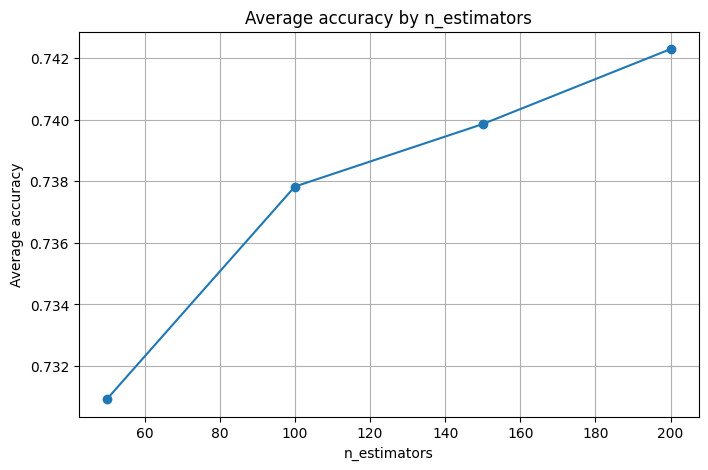

In [12]:
mean_by_estimators = results_df.groupby("n_estimators")["accuracy"].mean()

plt.figure(figsize=(8, 5))
plt.plot(mean_by_estimators.index, mean_by_estimators.values, marker="o")
plt.title("Average accuracy by n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Average accuracy")
plt.grid(True)
plt.show()

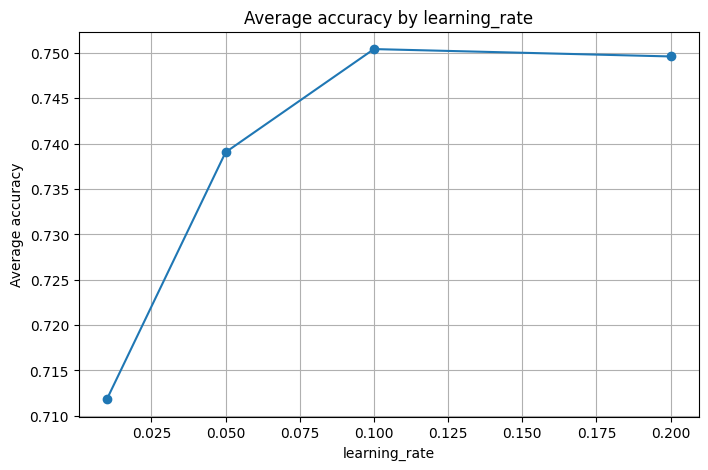

In [13]:
mean_by_learning_rate = results_df.groupby("learning_rate")["accuracy"].mean()

plt.figure(figsize=(8, 5))
plt.plot(mean_by_learning_rate.index, mean_by_learning_rate.values, marker="o")
plt.title("Average accuracy by learning_rate")
plt.xlabel("learning_rate")
plt.ylabel("Average accuracy")
plt.grid(True)
plt.show()

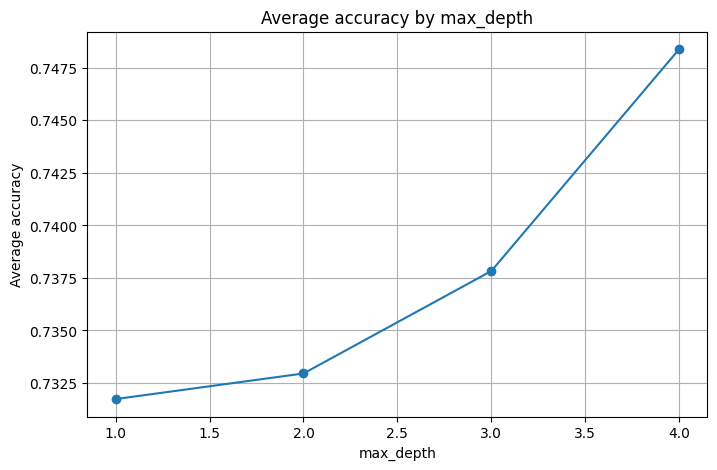

In [14]:
mean_by_depth = results_df.groupby("max_depth")["accuracy"].mean()

plt.figure(figsize=(8, 5))
plt.plot(mean_by_depth.index, mean_by_depth.values, marker="o")
plt.title("Average accuracy by max_depth")
plt.xlabel("max_depth")
plt.ylabel("Average accuracy")
plt.grid(True)
plt.show()

### Choose the best boosting model

In [15]:
best_boosting_row = results_df.sort_values(by="accuracy", ascending=False).iloc[0]

best_n_estimators = int(best_boosting_row["n_estimators"])
best_learning_rate = float(best_boosting_row["learning_rate"])
best_max_depth = int(best_boosting_row["max_depth"])

print("Best n_estimators:", best_n_estimators)
print("Best learning_rate:", best_learning_rate)
print("Best max_depth:", best_max_depth)
print("Best accuracy:", best_boosting_row["accuracy"])

Best n_estimators: 50
Best learning_rate: 0.2
Best max_depth: 4
Best accuracy: 0.7727272727272727


In [16]:
best_boosting_model = GradientBoostingClassifier(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=42
)

best_boosting_model.fit(X_train, y_train)
y_pred_best_boosting = best_boosting_model.predict(X_test)

print("Best boosting accuracy:", accuracy_score(y_test, y_pred_best_boosting))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_boosting))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_best_boosting))

Best boosting accuracy: 0.7727272727272727

Confusion Matrix:
[[85 15]
 [20 34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       100
           1       0.69      0.63      0.66        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



## Step 3: Save the model

Now we save the best boosting model in the `models` folder.

In [17]:
os.makedirs("models", exist_ok=True)

model_path = "models/boosting_diabetes.joblib"
joblib.dump(best_boosting_model, model_path)

print("Model saved at:", model_path)

Model saved at: models/boosting_diabetes.joblib


## Step 4: Analyze and compare model results

To compare the three approaches fairly, we will train:

- the best **Decision Tree**,
- the best **Random Forest**,
- the best **Boosting** model.

Then we will compare their accuracy and class performance.

### Best Decision Tree

In [18]:
dt_results = []

for max_depth in [2, 3, 4, 5, 6, 7, None]:
    for min_samples_split in [2, 5, 10, 20]:
        dt_model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42
        )

        dt_model.fit(X_train, y_train)
        y_pred_dt = dt_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred_dt)

        dt_results.append({
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "accuracy": accuracy
        })

dt_results_df = pd.DataFrame(dt_results)
dt_results_df.sort_values(by="accuracy", ascending=False).head()

,max_depth,min_samples_split,accuracy
8,4.0,2,0.785714
9,4.0,5,0.785714
10,4.0,10,0.785714
11,4.0,20,0.785714
14,5.0,10,0.766234


In [19]:
best_dt_row = dt_results_df.sort_values(by="accuracy", ascending=False).iloc[0]

best_dt_max_depth = best_dt_row["max_depth"]
best_dt_min_samples_split = int(best_dt_row["min_samples_split"])

if pd.isna(best_dt_max_depth):
    best_dt_max_depth = None
else:
    best_dt_max_depth = int(best_dt_max_depth)

best_dt_model = DecisionTreeClassifier(
    max_depth=best_dt_max_depth,
    min_samples_split=best_dt_min_samples_split,
    random_state=42
)

best_dt_model.fit(X_train, y_train)
y_pred_dt_best = best_dt_model.predict(X_test)

print("Best Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt_best))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_best))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_dt_best))

Best Decision Tree accuracy: 0.7857142857142857

Confusion Matrix:
[[84 16]
 [17 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       100
           1       0.70      0.69      0.69        54

    accuracy                           0.79       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.79      0.79       154



### Best Random Forest

In [20]:
rf_results = []

for n_estimators in [10, 50, 100, 200]:
    for max_depth in [3, 5, 7, 10, None]:
        rf_model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        rf_model.fit(X_train, y_train)
        y_pred_rf = rf_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred_rf)

        rf_results.append({
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "accuracy": accuracy
        })

rf_results_df = pd.DataFrame(rf_results)
rf_results_df.sort_values(by="accuracy", ascending=False).head()

,n_estimators,max_depth,accuracy
14,100,NaN,0.779221
4,10,NaN,0.772727
18,200,10.0,0.753247
13,100,10.0,0.753247
17,200,7.0,0.753247


In [21]:
best_rf_row = rf_results_df.sort_values(by="accuracy", ascending=False).iloc[0]

best_rf_n_estimators = int(best_rf_row["n_estimators"])
best_rf_max_depth = best_rf_row["max_depth"]

if pd.isna(best_rf_max_depth):
    best_rf_max_depth = None
else:
    best_rf_max_depth = int(best_rf_max_depth)

best_rf_model = RandomForestClassifier(
    n_estimators=best_rf_n_estimators,
    max_depth=best_rf_max_depth,
    random_state=42
)

best_rf_model.fit(X_train, y_train)
y_pred_rf_best = best_rf_model.predict(X_test)

print("Best Random Forest accuracy:", accuracy_score(y_test, y_pred_rf_best))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_best))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_best))

Best Random Forest accuracy: 0.7792207792207793

Confusion Matrix:
[[88 12]
 [22 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



### Compare the three final models

In [22]:
comparison_rows = []

models = {
    "Decision Tree": (best_dt_model, y_pred_dt_best),
    "Random Forest": (best_rf_model, y_pred_rf_best),
    "Boosting": (best_boosting_model, y_pred_best_boosting)
}

for model_name, (model, y_pred) in models.items():
    report = classification_report(y_test, y_pred, output_dict=True)

    recall_class_0 = report["0"]["recall"]
    recall_class_1 = report["1"]["recall"]

    if recall_class_0 >= recall_class_1:
        best_class = "Class 0"
        worst_class = "Class 1"
    else:
        best_class = "Class 1"
        worst_class = "Class 0"

    comparison_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall class 0": recall_class_0,
        "Recall class 1": recall_class_1,
        "Best predicted class": best_class,
        "Worst predicted class": worst_class
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Recall class 0,Recall class 1,Best predicted class,Worst predicted class
0,Decision Tree,0.785714,0.84,0.685185,Class 0,Class 1
1,Random Forest,0.779221,0.88,0.592593,Class 0,Class 1
2,Boosting,0.772727,0.85,0.629630,Class 0,Class 1


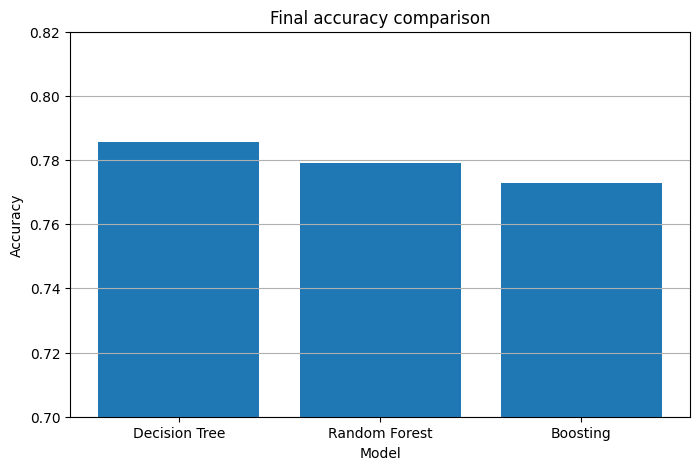

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Final accuracy comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.70, 0.82)
plt.grid(axis="y")
plt.show()

In [20]:
best_model_name = comparison_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_model_accuracy = comparison_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Accuracy"]

print("Best model based on accuracy:", best_model_name)
print("Best accuracy:", round(best_model_accuracy, 4))
print()

for _, row in comparison_df.sort_values(by="Accuracy", ascending=False).iterrows():
    print(row["Model"])
    print("  Accuracy:", round(row["Accuracy"], 4))
    print("  Best predicted class:", row["Best predicted class"])
    print("  Worst predicted class:", row["Worst predicted class"])
    print()

Best model based on accuracy: Decision Tree
Best accuracy: 0.7857

Decision Tree
  Accuracy: 0.7857
  Best predicted class: Class 0
  Worst predicted class: Class 1

Random Forest
  Accuracy: 0.7792
  Best predicted class: Class 0
  Worst predicted class: Class 1

Boosting
  Accuracy: 0.7727
  Best predicted class: Class 0
  Worst predicted class: Class 1

